<a href="https://colab.research.google.com/github/hazra-kerubo/Logistic-Model/blob/main/Heat_OIL_LinearRegression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question

Develop a model for estimating heating oil used for a single family
home in the month of January based on average temperature and
amount of insulation in inches.

 a) What preliminary conclusions can home owners draw from the
data?

 b) What could a home owner expect heating oil consumption (in
gallons) to be if the outside temperature is 15 oF when the attic
insulation is 10 inches thick?

In [ ]:
import seaborn as sns


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load data
df2 =  pd.read_csv('/content/Heat oil Gas Temperature - Sheet1 (1).csv')
df2

,Oil,Temperature,Insulation
0,275.3,40,3
1,363.8,27,3
2,164.3,40,10
3,40.8,73,6
4,94.3,64,6
5,230.9,34,6
6,366.7,9,6
7,300.6,8,10
8,237.8,23,10
9,121.4,63,3


In [ ]:
#Numerical variable analysis - checking staticts such as mean ,mode std deviation 50th percentile etc
df2.describe()

,Oil,Temperature,Insulation
count,15.000000,15.000000,15.000000
mean,216.493333,40.266667,6.333333
std,129.872253,20.679412,2.968084
min,31.400000,8.000000,3.000000
25%,107.850000,25.000000,3.000000
50%,230.900000,40.000000,6.000000
75%,311.800000,60.500000,10.000000
max,441.100000,73.000000,10.000000


In [ ]:
# checking datatypes so we have int and float dtypes
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Oil          15 non-null     float64
 1   Temperature  15 non-null     int64  
 2   Insulation   15 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 492.0 bytes


**Univariate Analysis**

<ipython-input-84-56737f836644>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['Insulation']) # Has a normal distribution


<Axes: xlabel='Insulation', ylabel='Density'>

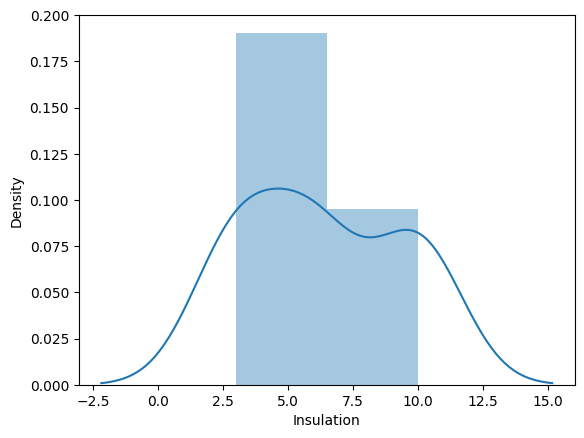

In [ ]:
sns.distplot(df2['Insulation']) # Has a normal distribution


<ipython-input-85-a0638bfc1f08>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['Oil'])


<Axes: xlabel='Oil', ylabel='Density'>

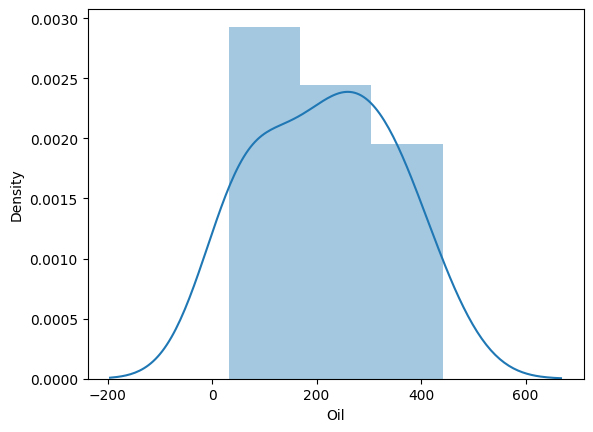

In [ ]:
sns.distplot(df2['Oil'])

In [ ]:
df2['Insulation'].skew() # the data is postitive hence its rigt skewed

0.19262444509155688

In [ ]:
df2['Temperature'].skew() # the data is postitive hence its rigt skewed

0.01718723371306492

In [ ]:
df2['Oil'].skew() # the data is postitive hence its rigt skewed

0.035060589551896205

<Axes: ylabel='Oil'>

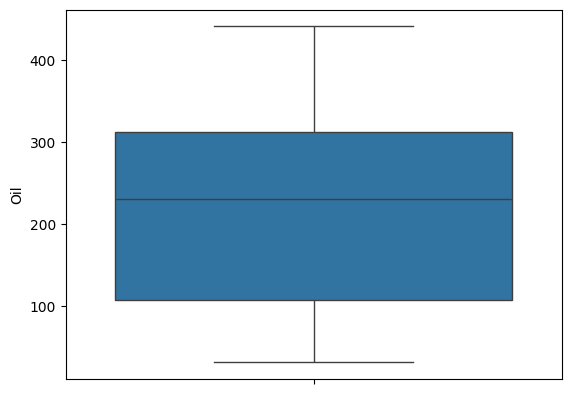

In [ ]:
sns.boxplot(df2['Oil']) # Oil has a minimum value of abot 50 to 450 and a median of 250 also known as 2nd quartile

**Model**

In [ ]:
# Split data into features and target
X = df2[['Temperature', 'Insulation']]
y = df2['Oil']


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
X_train

,Temperature,Insulation
8,23,10
2,40,10
1,27,3
14,58,10
4,64,6
7,8,10
10,65,10
12,21,3
3,73,6
6,9,6


In [ ]:
X_test

,Temperature,Insulation
9,63,3
11,41,6
0,40,3
13,38,3
5,34,6


In [ ]:
y_train

,Oil
8,237.8
2,164.3
1,363.8
14,52.5
4,94.3
7,300.6
10,31.4
12,441.1
3,40.8
6,366.7


In [ ]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)


In [ ]:
# Checking Y intercept
c = model.intercept_
c


576.3295782534407

In [ ]:
# Checking coeefficients for the training features -- we have two coeeff for the two training features
m = model.coef_
m

array([ -5.24184793, -22.11025388])

Plotting

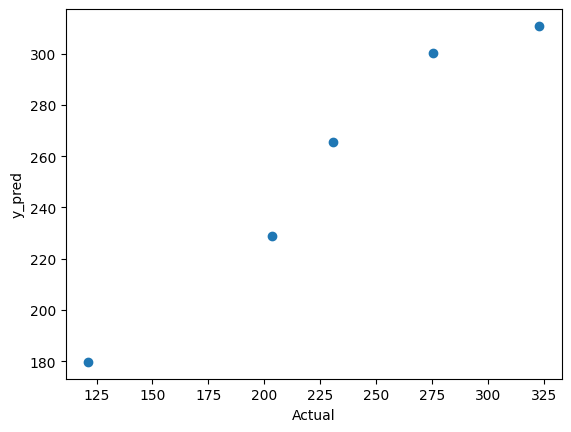

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('y_pred')
plt.show()

In [ ]:
# Evaluate model
y_pred = model.predict(X_test)
print("R-Squared:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


R-Squared: 0.7407992486320011
Mean Absolute Error: 31.075243373048863


In [ ]:
# Predict example
predicted_oil = model.predict([[15, 10]]) #  15 degrees, 10 inches insulation
print("Predicted Oil Consumption:", predicted_oil)


Predicted Oil Consumption: [276.59932056]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Predict example 2
predicted_oil2 = model.predict([[100, 20]]) # Example: 100 degress , 5 inches insulation
print("Predicted Oil Consumption:", predicted_oil2)

Predicted Oil Consumption: [-390.06029198]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Conclusion**

1. At a temperature of 15°F and 10 inches of insulation, the estimated oil consumption was approximately 276.59 gallons.
2. Homes with better insulation and higher temperatures consume oil more
 efficiently, while homes with low insulation in extreme cold conditions have higher consumption levels.
3. Homeowners can use the model to optimize heating oil usage by
Upgrading insulation thickness to reduce consumption &
Anticipating heating oil needs based on weather patterns.
